# 10 — Policy Scenario Comparison

Runs NSGA-II evolution under 5 different policy scenarios and compares:
- Pareto fronts (all overlaid)
- Action maps per scenario
- Summary statistics

Uses the learned carbon model with pre-computed forest GBR predictions.

**Expected runtime:** ~40-60 min total (5 scenarios × 200 pop × 200 gen)

In [1]:
import sys
sys.path.insert(0, "../src")

import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import time
from estonia_landuse.optimizer.trainer import train as run_evolution
from estonia_landuse.scenarios import build_scenario_summary, select_scenario_representatives
from estonia_landuse.simulator.config import default_config
from estonia_landuse.simulator.simulator import summarize_policy
from estonia_landuse.simulator.targets import realize_targets

## Configuration

In [2]:
POP_SIZE = 200
N_GENERATIONS = 200

DATA_DIR = Path("../data/processed/learned_carbon")
RESULTS_DIR = DATA_DIR

## Load data

All features pre-computed by notebook 09 (includes forest, peat, rohemeeter).

In [3]:
features_df = pd.read_parquet(DATA_DIR / "features_with_forest.parquet")

if "predicted_tco2_ha_yr" not in features_df.columns:
    raise FileNotFoundError(
        "Missing prepared predicted_tco2_ha_yr. "
        "Run notebook 09_spatial_join_and_model.ipynb first."
    )

valid_carbon = features_df["predicted_tco2_ha_yr"].dropna()
print(
    "Prepared cell carbon predictions: "
    f"{len(valid_carbon):,}/{len(features_df):,} cells, "
    f"mean={valid_carbon.mean():.2f} tCO2/ha/yr"
)

# Feature columns for prescriptor
FEATURE_COLUMNS = [
    "urban_pct", "agriculture_pct", "grassland_pct", "forest_pct",
    "wetland_pct", "water_pct", "naturalness_score", "carbon_score",
    "protected_overlap_pct", "wetland_suitability", "biodiversity_proxy",
    "opportunity_cost_proxy", "rohemeeter_norm",
]
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c in features_df.columns]

# Grid for maps
grid = gpd.read_file("../data/processed/v1/base_grid.gpkg")
print(f"Loaded: {len(features_df)} cells, {len(FEATURE_COLUMNS)} features")
print(f"  peat_overlap_pct: mean={features_df['peat_overlap_pct'].mean():.3f}, >0: {(features_df['peat_overlap_pct']>0).sum()}")
print(f"  rohemeeter_norm: mean={features_df.get('rohemeeter_norm', pd.Series(0)).mean():.3f}")

Prepared cell carbon predictions: 7,343/11,224 cells, mean=4.49 tCO2/ha/yr
Loaded: 11224 cells, 13 features
  peat_overlap_pct: mean=0.236, >0: 4998
  rohemeeter_norm: mean=0.537


## Define scenarios

In [4]:
def make_scenario_config(scenario_name):
    """Create a config dict for each scenario with aggressive differentiation."""
    config = default_config()
    config["carbon_model"] = "learned"

    if scenario_name == "green_maximum":
        # Maximum ecological gain — relax all economic constraints
        config["scoring"]["agriculture_loss_cost"] = 0.3
        config["max_total_agri_loss_pct"] = 0.50
        config["max_changed_pct"] = 0.40
        config["budget_penalty_weight"] = 3.0
        config["total_agri_loss_penalty_weight"] = 5.0

    elif scenario_name == "food_security":
        # Preserve farmland at all costs
        config["scoring"]["agriculture_loss_cost"] = 15.0
        config["max_total_agri_loss_pct"] = 0.03
        config["total_agri_loss_penalty_weight"] = 100.0
        config["max_changed_pct"] = 0.15

    elif scenario_name == "low_budget":
        # Minimal intervention — what can you achieve cheaply?
        config["max_changed_pct"] = 0.06
        config["max_total_agri_loss_pct"] = 0.15
        config["budget_penalty_weight"] = 50.0
        config["scoring"]["base_change_cost"] = 2.0

    elif scenario_name == "wetland_priority":
        # Prioritize wetland restoration — relax constraints on wetland
        config["constraints"]["wetland_suit_min_for_restore"] = 0.05
        config["scoring"]["biodiversity_value"] = [0.4, 1.0, 0.1, 0.3]
        config["max_changed_pct"] = 0.25
        config["max_total_agri_loss_pct"] = 0.15
        config["max_total_agri_gain_pct"] = 0.05
        config["max_gross_agri_gain_pct"] = 0.15
        config["scoring"]["agriculture_gain_cost"] = 10.0
        config["optimization"] = {}
        config["optimization"]["fourth_objective"] = "wetland_gain_pct"
        config["budget_penalty_weight"] = 5.0

    elif scenario_name == "sustainable_agriculture":
        # Expand agriculture within ecological and relocation safeguards
        config["max_changed_pct"] = 0.15
        config["max_total_agri_loss_pct"] = 1.0
        config["min_total_agri_gain_pct"] = 0.05
        config["max_total_agri_gain_pct"] = 0.10
        config["max_gross_agri_loss_pct"] = 0.02
        config["min_biodiversity_gain"] = -0.01
        config["min_carbon_gain"] = -0.01
        config["scoring"]["agriculture_loss_cost"] = 30.0
        config["scoring"]["agriculture_gain_cost"] = 0.3
        config["optimization"] = {}
        config["optimization"]["fourth_objective"] = "agriculture_gain_pct"

    elif scenario_name == "balanced":
        config["max_changed_pct"] = 0.20
        config["max_total_agri_loss_pct"] = 0.15

    return config


SCENARIOS = {
    "green_maximum": "Green Maximum (low agri protection)",
    "food_security": "Food Security (preserve farmland)",
    "low_budget": "Low Budget (minimal intervention)",
    "wetland_priority": "Wetland Priority (rewetting focus)",
    "sustainable_agriculture": "Sustainable Agriculture Expansion",
    "balanced": "Balanced (default)",
}
SELECTION_RULES = {
    "green_maximum": "green_maximum",
    "food_security": "food_security",
    "low_budget": "low_budget",
    "wetland_priority": "wetland_priority",
    "sustainable_agriculture": "sustainable_agriculture",
    "balanced": "balanced",
}

print("Scenarios defined:")
for key, desc in SCENARIOS.items():
    print(f"  {key}: {desc}")

Scenarios defined:
  green_maximum: Green Maximum (low agri protection)
  food_security: Food Security (preserve farmland)
  low_budget: Low Budget (minimal intervention)
  wetland_priority: Wetland Priority (rewetting focus)
  sustainable_agriculture: Sustainable Agriculture Expansion
  balanced: Balanced (default)


## Run evolution for each scenario

In [5]:
results = {}
for scenario_name, description in SCENARIOS.items():
    config = make_scenario_config(scenario_name)

    print(f"\n{'='*60}")
    print(f"Scenario: {description}")
    print(f"  pop={POP_SIZE}, gen={N_GENERATIONS}")
    t0 = time.time()

    pop = run_evolution(
        context=features_df,
        feature_columns=FEATURE_COLUMNS,
        pop_size=POP_SIZE,
        n_generations=N_GENERATIONS,
        config=config,
        seed=42,
        verbose=True,
    )

    dt = time.time() - t0
    front0 = [p for p in pop if p.rank == 0]
    results[scenario_name] = {
        "pop": pop, "front0": front0, "config": config,
        "time": dt, "description": description,
    }
    print(f"  Done in {dt:.0f}s, front-0: {len(front0)}")

print(f"\n\nTotal time: {sum(r['time'] for r in results.values())/60:.1f} min")


Scenario: Green Maximum (low agri protection)
  pop=200, gen=200
Created 4 seed prescriptors
Gen  10 | Front-0:  42 | Avg: bio=0.0091 carbon=-0.0019 cost=0.5399 change=16.2%
Gen  20 | Front-0: 129 | Avg: bio=0.0171 carbon=0.0234 cost=0.3357 change=11.5%
Gen  30 | Front-0: 200 | Avg: bio=0.0203 carbon=0.0301 cost=0.3280 change=10.6%
Gen  40 | Front-0: 200 | Avg: bio=0.0210 carbon=0.0299 cost=0.3640 change=10.0%
Gen  50 | Front-0: 200 | Avg: bio=0.0218 carbon=0.0301 cost=0.3740 change=9.8%
Gen  60 | Front-0: 200 | Avg: bio=0.0214 carbon=0.0298 cost=0.3766 change=9.4%
Gen  70 | Front-0: 200 | Avg: bio=0.0217 carbon=0.0296 cost=0.3809 change=9.2%
Gen  80 | Front-0: 200 | Avg: bio=0.0224 carbon=0.0312 cost=0.3818 change=9.3%
Gen  90 | Front-0: 200 | Avg: bio=0.0217 carbon=0.0304 cost=0.3598 change=9.0%
Gen 100 | Front-0: 200 | Avg: bio=0.0228 carbon=0.0316 cost=0.3836 change=9.2%
Gen 110 | Front-0: 200 | Avg: bio=0.0216 carbon=0.0296 cost=0.3593 change=8.8%
Gen 120 | Front-0: 200 | Avg: bi

## Evaluate Pareto fronts

In [6]:
# Evaluate each scenario's front with its own config
def get_pareto_df(population, context, config):
    features = context[FEATURE_COLUMNS].values.astype(np.float32)
    feat_mean = features.mean(axis=0)
    feat_std = features.std(axis=0)
    feat_std[feat_std == 0] = 1.0
    feat_norm = (features - feat_mean) / feat_std
    rows = []
    for i, p in enumerate(population):
        if p.rank != 0:
            continue
        targets = p.prescribe(feat_norm)
        s = summarize_policy(context, targets, config)
        s["id"] = i
        rows.append(s)
    return pd.DataFrame(rows), feat_norm

pareto_dfs = {}
for name, data in results.items():
    pdf, feat_norm = get_pareto_df(data["pop"], features_df, data["config"])
    pareto_dfs[name] = pdf
    print(f"{name}: {len(pdf)} front-0 policies")

green_maximum: 200 front-0 policies
food_security: 200 front-0 policies
low_budget: 200 front-0 policies
wetland_priority: 94 front-0 policies
sustainable_agriculture: 3 front-0 policies
balanced: 200 front-0 policies


## All Pareto Fronts (overlaid)

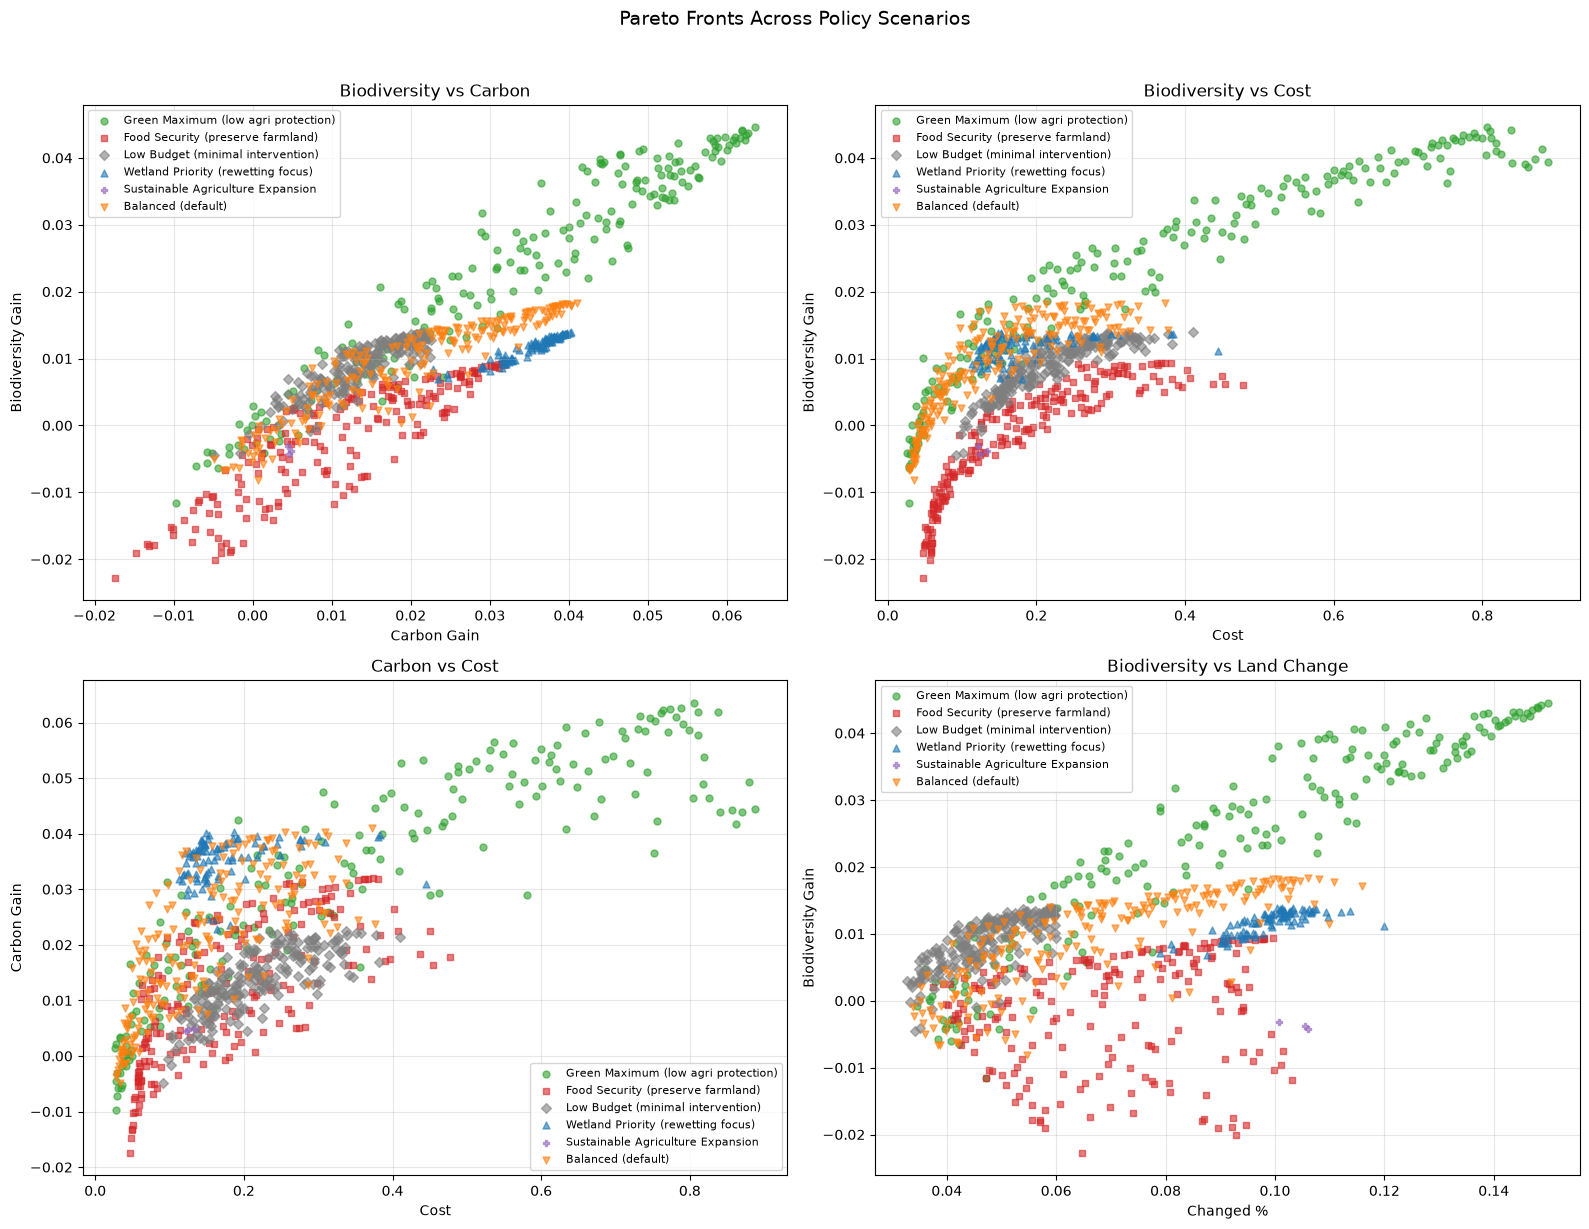

In [7]:
colors = {
    "green_maximum": "tab:green",
    "food_security": "tab:red",
    "low_budget": "tab:gray",
    "wetland_priority": "tab:blue",
    "sustainable_agriculture": "tab:purple",
    "balanced": "tab:orange",
}

markers = {
    "green_maximum": "o",
    "food_security": "s",
    "low_budget": "D",
    "wetland_priority": "^",
    "sustainable_agriculture": "P",
    "balanced": "v",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bio vs Carbon
ax = axes[0, 0]
for name, pdf in pareto_dfs.items():
    ax.scatter(pdf["carbon_gain"], pdf["biodiversity_gain"],
               alpha=0.6, s=25, label=SCENARIOS[name],
               color=colors[name], marker=markers[name])
ax.set_xlabel("Carbon Gain"); ax.set_ylabel("Biodiversity Gain")
ax.set_title("Biodiversity vs Carbon"); 
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bio vs Cost
ax = axes[0, 1]
for name, pdf in pareto_dfs.items():
    ax.scatter(pdf["cost"], pdf["biodiversity_gain"],
               alpha=0.6, s=25, label=SCENARIOS[name],
               color=colors[name], marker=markers[name])
ax.set_xlabel("Cost"); ax.set_ylabel("Biodiversity Gain")
ax.set_title("Biodiversity vs Cost"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Carbon vs Cost
ax = axes[1, 0]
for name, pdf in pareto_dfs.items():
    ax.scatter(pdf["cost"], pdf["carbon_gain"],
               alpha=0.6, s=25, label=SCENARIOS[name],
               color=colors[name], marker=markers[name])
ax.set_xlabel("Cost"); ax.set_ylabel("Carbon Gain")
ax.set_title("Carbon vs Cost"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bio vs Change%
ax = axes[1, 1]
for name, pdf in pareto_dfs.items():
    ax.scatter(pdf["changed_pct"], pdf["biodiversity_gain"],
               alpha=0.6, s=25, label=SCENARIOS[name],
               color=colors[name], marker=markers[name])
ax.set_xlabel("Changed %"); ax.set_ylabel("Biodiversity Gain")
ax.set_title("Biodiversity vs Land Change"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Pareto Fronts Across Policy Scenarios", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

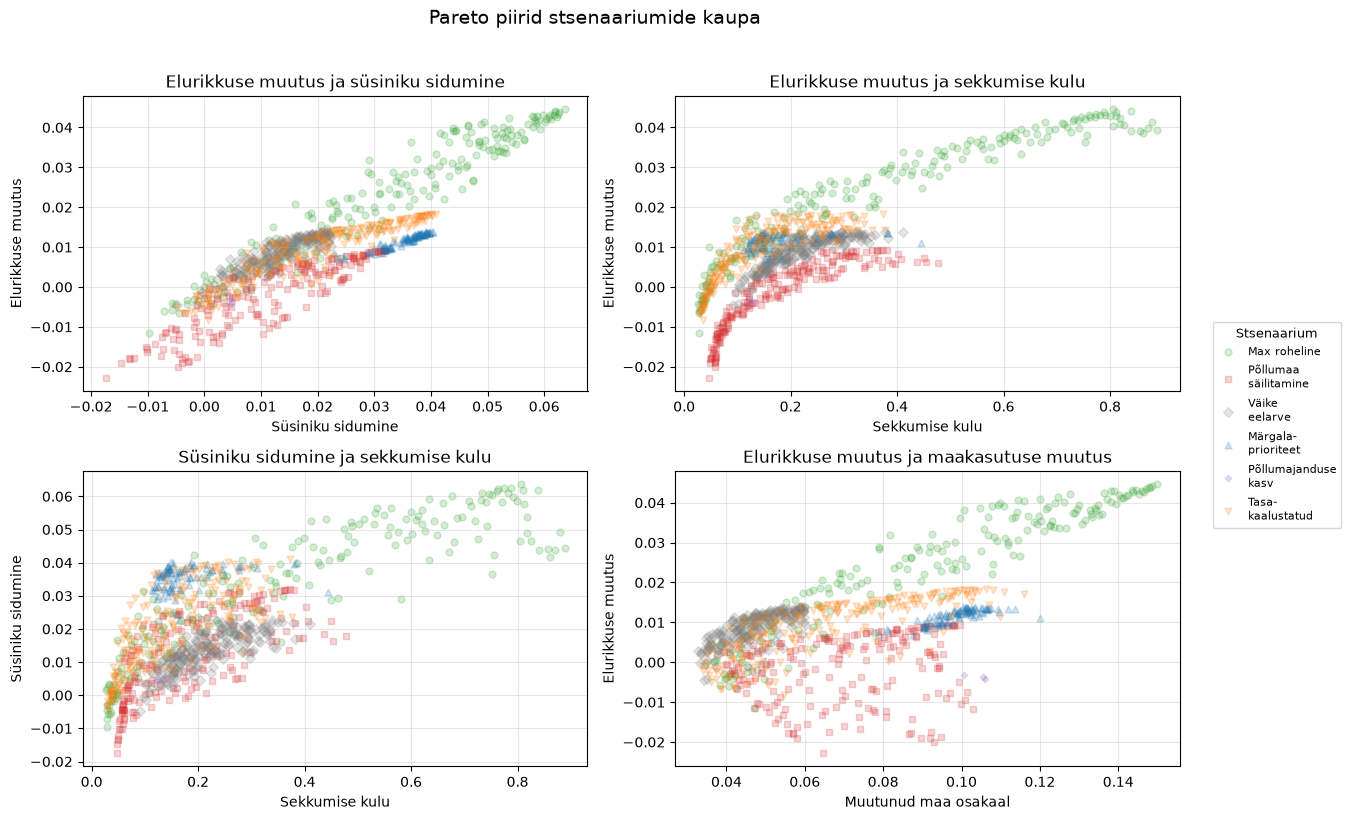

In [53]:
colors = {
    "green_maximum": "tab:green",
    "food_security": "tab:red",
    "low_budget": "tab:gray",
    "wetland_priority": "tab:blue",
    "sustainable_agriculture": "tab:purple",
    "balanced": "tab:orange",
}

markers = {
    "green_maximum": "o",
    "food_security": "s",
    "low_budget": "D",
    "wetland_priority": "^",
    "sustainable_agriculture": "P",
    "balanced": "v",
}

# SCENARIOS_ET = {
#     "green_maximum": "Maksimaalne rohelahendus",
#     "food_security": "Toidujulgeolek",
#     "low_budget": "Väike eelarve",
#     "wetland_priority": "Märgala prioriteet",
#     "sustainable_agriculture": "Kestlik põllumajanduse laiendamine",
#     "balanced": "Tasakaalustatud",
# }
SCENARIOS_ET = {
    "green_maximum": "Max roheline",
    "food_security": "Põllumaa\nsäilitamine",
    "low_budget": "Väike\neelarve",
    "wetland_priority": "Märgala-\nprioriteet",
    "sustainable_agriculture": "Põllumajanduse\nkasv",
    "balanced": "Tasa-\nkaalustatud",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Elurikkus vs süsinik
ax = axes[0, 0]
for name, pdf in pareto_dfs.items():
    ax.scatter(
        pdf["carbon_gain"],
        pdf["biodiversity_gain"],
        alpha=0.2,
        s=25,
        label=SCENARIOS_ET[name],
        color=colors[name],
        marker=markers[name],
    )
ax.set_xlabel("Süsiniku sidumine")
ax.set_ylabel("Elurikkuse muutus")
ax.set_title("Elurikkuse muutus ja süsiniku sidumine")
#ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Elurikkus vs kulu
ax = axes[0, 1]
for name, pdf in pareto_dfs.items():
    ax.scatter(
        pdf["cost"],
        pdf["biodiversity_gain"],
        alpha=0.2,
        s=25,
        label=SCENARIOS_ET[name],
        color=colors[name],
        marker=markers[name],
    )
ax.set_xlabel("Sekkumise kulu")
ax.set_ylabel("Elurikkuse muutus")
ax.set_title("Elurikkuse muutus ja sekkumise kulu")
#ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Süsinik vs kulu
ax = axes[1, 0]
for name, pdf in pareto_dfs.items():
    ax.scatter(
        pdf["cost"],
        pdf["carbon_gain"],
        alpha=0.2,
        s=25,
        label=SCENARIOS_ET[name],
        color=colors[name],
        marker=markers[name],
    )
ax.set_xlabel("Sekkumise kulu")
ax.set_ylabel("Süsiniku sidumine")
ax.set_title("Süsiniku sidumine ja sekkumise kulu")
#ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Elurikkus vs muutunud maa
ax = axes[1, 1]
for name, pdf in pareto_dfs.items():
    ax.scatter(
        pdf["changed_pct"],
        pdf["biodiversity_gain"],
        alpha=0.2,
        s=25,
        label=SCENARIOS_ET[name],
        color=colors[name],
        marker=markers[name],
    )
ax.set_xlabel("Muutunud maa osakaal")
ax.set_ylabel("Elurikkuse muutus")
ax.set_title("Elurikkuse muutus ja maakasutuse muutus")
#ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Take the scenario markers and labels from the first subplot.
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Stsenaarium",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8,
    title_fontsize=9,
)

plt.suptitle("Pareto piirid stsenaariumide kaupa", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
plt.close(fig)

## Summary table

In [9]:
representatives = select_scenario_representatives(
    pareto_dfs,
    SELECTION_RULES,
)
selected_policies = {
    name: results[name]["pop"][int(row["id"])]
    for name, row in representatives.items()
}
summary = build_scenario_summary(
    pareto_dfs,
    representatives=representatives,
    selection_rules=SELECTION_RULES,
    scenario_labels=SCENARIOS,
    elapsed_seconds={name: data["time"] for name, data in results.items()},
)
print(summary.set_index("Scenario").to_string(float_format="{:.3f}".format))

                                       Status           Selection rule  Policy ID  Biodiversity gain  Carbon gain  Cost  Changed land  Agriculture loss  Agriculture gain  Gross agriculture loss  Gross agriculture gain  Wetland gain  Constraint violation  Feasible solutions  Front size  Time (s)
Scenario                                                                                                                                                                                                                                                                                               
Green Maximum (low agri protection)  feasible            green_maximum          1              0.045        0.064 0.806         0.150             0.499             0.000                   0.500                   0.002         0.000                 0.000                 200         200   839.518
Food Security (preserve farmland)    feasible            food_security          0              0.009        0.03

In [10]:
summary.round(3)

,Scenario,Status,Selection rule,Policy ID,Biodiversity gain,Carbon gain,Cost,Changed land,Agriculture loss,Agriculture gain,Gross agriculture loss,Gross agriculture gain,Wetland gain,Constraint violation,Feasible solutions,Front size,Time (s)
0,Green Maximum (low agri protection),feasible,green_maximum,1,0.045,0.064,0.806,0.150,0.499,0.000,0.500,0.002,0.000,0.0,200,200,839.518
1,Food Security (preserve farmland),feasible,food_security,0,0.009,0.032,0.367,0.098,0.030,0.000,0.100,0.071,0.000,0.0,200,200,696.168
2,Low Budget (minimal intervention),feasible,low_budget,126,0.012,0.018,0.200,0.052,0.126,0.000,0.149,0.022,0.000,0.0,200,200,1480.820
3,Wetland Priority (rewetting focus),feasible,wetland_priority,90,0.014,0.039,0.152,0.102,0.147,0.000,0.157,0.010,0.018,0.0,94,94,1456.931
4,Sustainable Agriculture Expansion,feasible,sustainable_agriculture,1,-0.004,0.005,0.133,0.105,0.000,0.094,0.020,0.114,0.000,0.0,3,3,1388.480
5,Balanced (default),feasible,balanced,185,0.013,0.024,0.147,0.067,0.131,0.000,0.156,0.025,0.000,0.0,200,200,1464.278


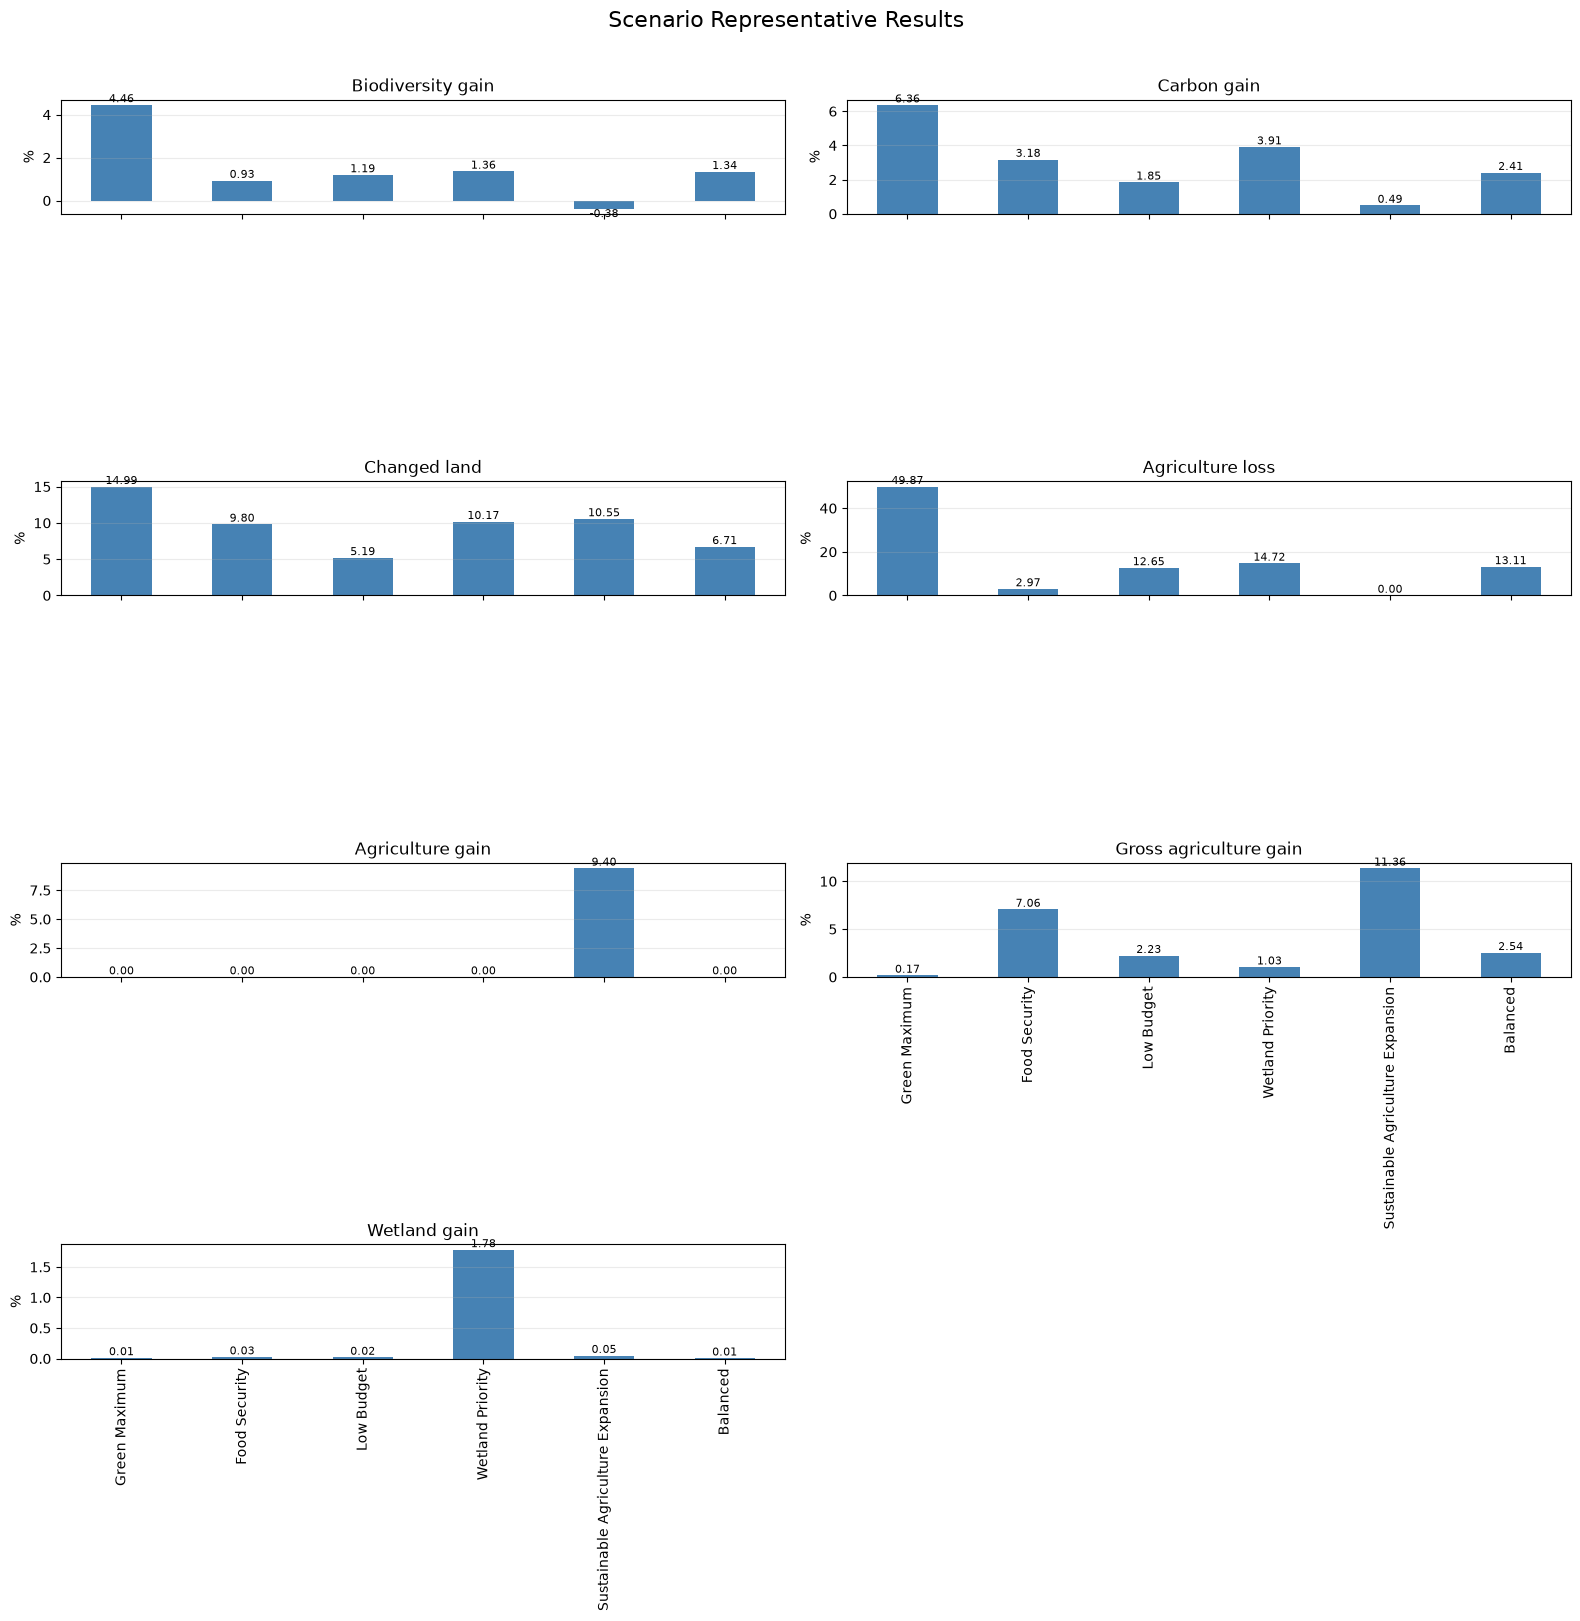

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

metrics = [
    "Biodiversity gain",
    "Carbon gain",
    "Changed land",
    "Agriculture loss",
    "Agriculture gain",
    "Gross agriculture gain",
    "Wetland gain",
]

plot_df = summary[metrics].copy() * 100

# Use the Scenario column when summary has an integer index
if "Scenario" in summary.columns:
    scenario_labels = summary["Scenario"].astype(str)
else:
    scenario_labels = pd.Series(summary.index.astype(str))

plot_df.index = (
    scenario_labels
    .str.replace(r" \(.*\)", "", regex=True)
    .to_numpy()
)

axes = plot_df.plot(
    kind="bar",
    subplots=True,
    layout=(4, 2),
    figsize=(16, 16),
    legend=False,
    sharex=True,
    color="steelblue",
)

for ax, metric in zip(axes.flat, metrics):
    ax.set_title(metric)
    ax.set_ylabel("%")
    ax.grid(axis="y", alpha=0.25)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8)

for ax in axes.flat[len(metrics):]:
    ax.set_visible(False)

plt.suptitle("Scenario Representative Results", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

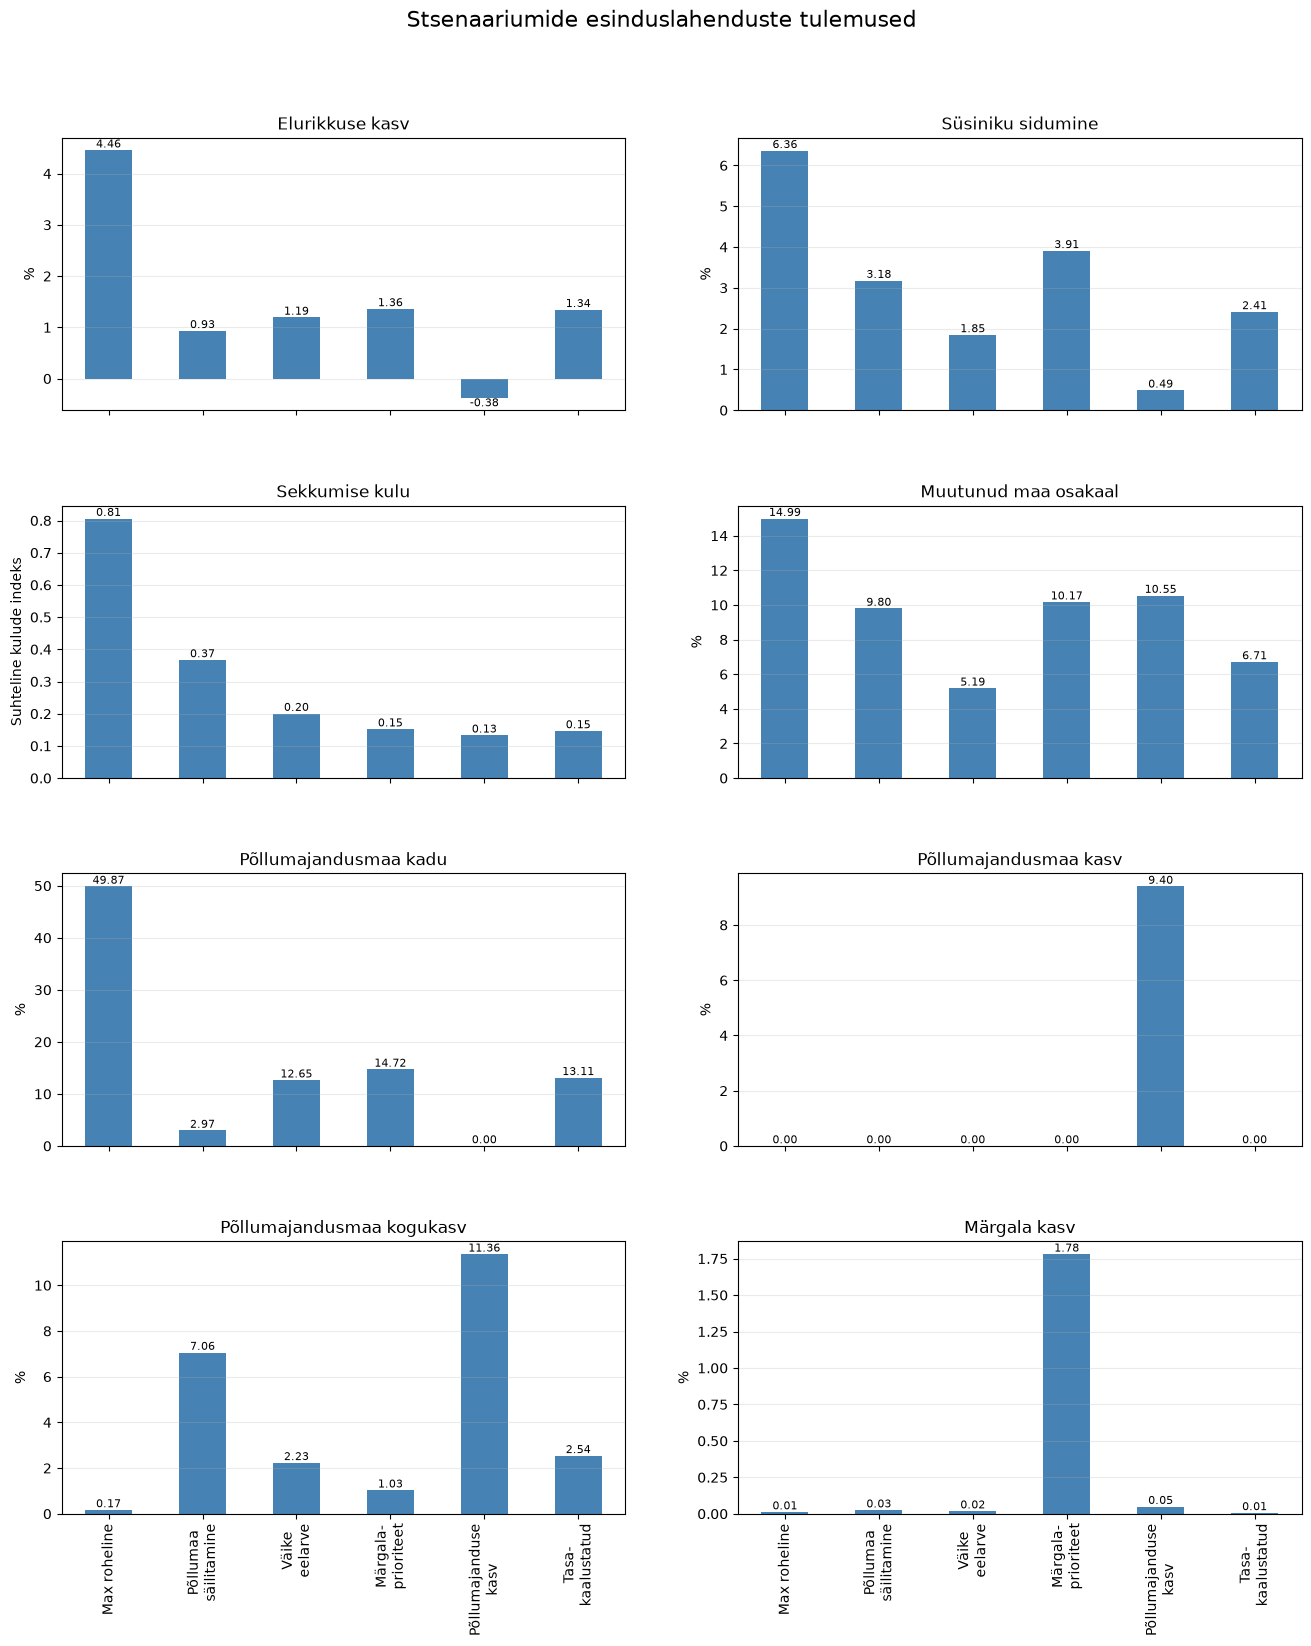

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

scenario_labels_et = {
    "Green Maximum": "Max roheline",
    "Food Security": "Põllumaa\nsäilitamine",
    "Low Budget": "Väike\neelarve",
    "Wetland Priority": "Märgala-\nprioriteet",
    "Sustainable Agriculture Expansion": "Põllumajanduse\nkasv",
    "Balanced": "Tasa-\nkaalustatud",
}

metrics = [
    "Biodiversity gain",
    "Carbon gain",
    "Cost",
    "Changed land",
    "Agriculture loss",
    "Agriculture gain",
    "Gross agriculture gain",
    "Wetland gain",
]

percent_metrics = [
    "Biodiversity gain",
    "Carbon gain",
    "Changed land",
    "Agriculture loss",
    "Agriculture gain",
    "Gross agriculture gain",
    "Wetland gain",
]

metric_labels_et = {
    "Biodiversity gain": "Elurikkuse kasv",
    "Carbon gain": "Süsiniku sidumine",
    "Cost": "Sekkumise kulu",
    "Changed land": "Muutunud maa osakaal",
    "Agriculture loss": "Põllumajandusmaa kadu",
    "Agriculture gain": "Põllumajandusmaa kasv",
    "Gross agriculture gain": "Põllumajandusmaa kogukasv",
    "Wetland gain": "Märgala kasv",
}

plot_df = summary[metrics].copy()

# Ainult osakaalud teisendatakse protsendiks.
plot_df[percent_metrics] = plot_df[percent_metrics] * 100

# plot_df = summary[metrics].copy() * 100

# Kasutab Scenario veergu, kui summary indeks on täisarv
if "Scenario" in summary.columns:
    scenario_labels = summary["Scenario"].astype(str)
else:
    scenario_labels = pd.Series(summary.index.astype(str))

# Eemaldab sulgudes oleva lisakirjelduse ja tõlgib stsenaariumi nime
scenario_labels = scenario_labels.str.replace(r" \(.*\)", "", regex=True)

plot_df.index = (
    scenario_labels
    .map(scenario_labels_et)
    .fillna(scenario_labels)
    .to_numpy()
)

axes = plot_df.plot(
    kind="bar",
    subplots=True,
    layout=(4, 2),
    figsize=(16, 16),
    legend=False,
    sharex=True,
    color="steelblue",
)

# for ax, metric in zip(axes.flat, metrics):
#     ax.set_title(metric_labels_et[metric])
#     ax.set_ylabel("%")
#     ax.grid(axis="y", alpha=0.25)

#     for container in ax.containers:
#         ax.bar_label(container, fmt="%.2f", fontsize=8)
for ax, metric in zip(axes.flat, metrics):
    unit = "%" if metric in percent_metrics else "Suhteline kulude indeks"

    ax.set_title(metric_labels_et[metric])
    ax.set_ylabel(unit)
    ax.grid(axis="y", alpha=0.25)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8)

for ax in axes.flat[len(metrics):]:
    ax.set_visible(False)

plt.suptitle("Stsenaariumide esinduslahenduste tulemused", fontsize=16, y=1.01)
fig = axes.flat[0].get_figure()

fig.subplots_adjust(
    hspace=0.35,  # vertical space between charts
    wspace=0.20,  # horizontal space between charts
    top=0.93,
    bottom=0.07,
)

plt.show()

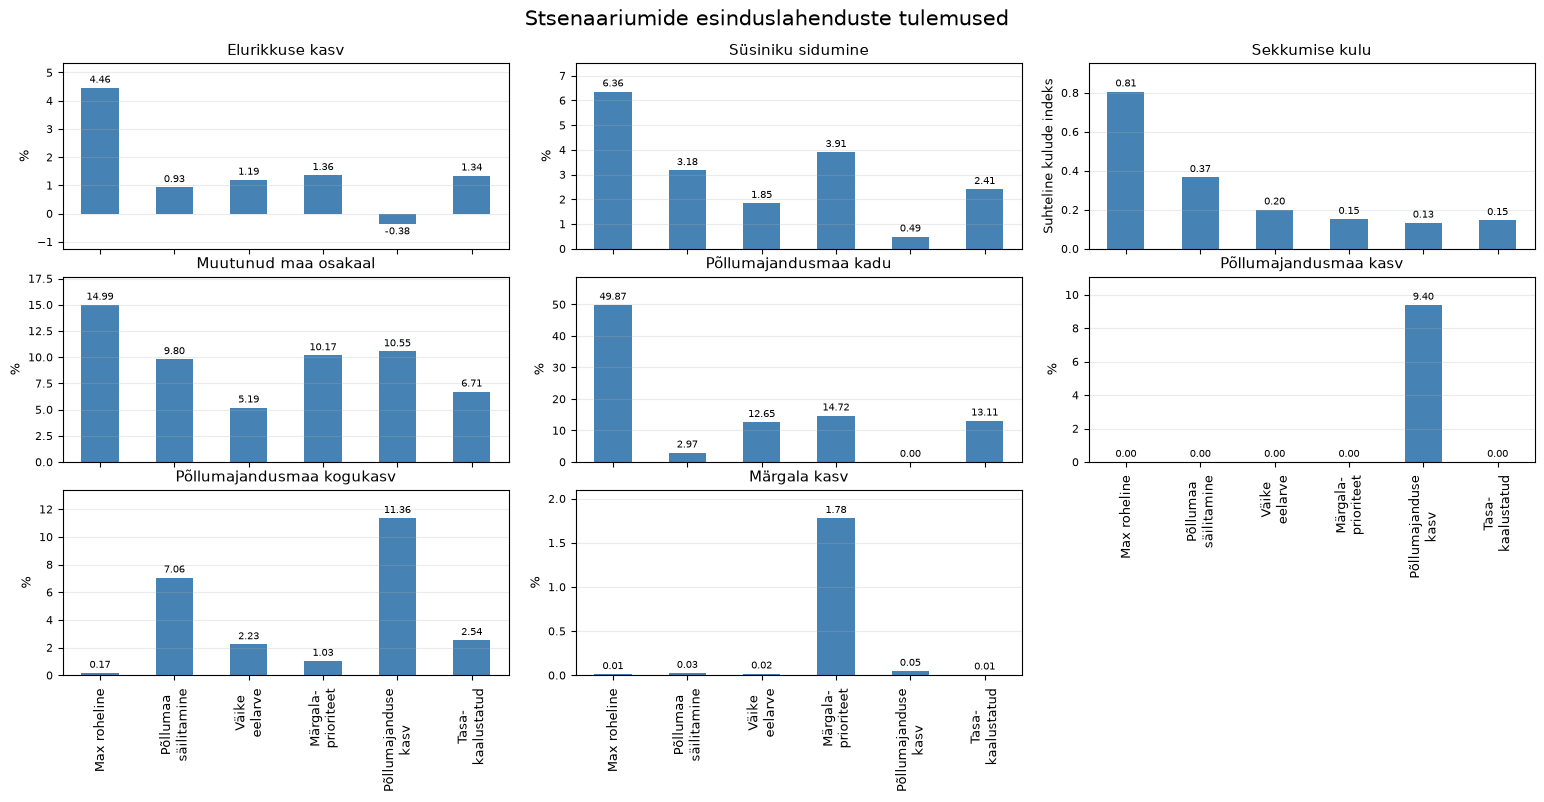

In [49]:
scenario_labels_et = {
    "Green Maximum": "Max roheline",
    "Food Security": "Põllumaa\nsäilitamine",
    "Low Budget": "Väike\neelarve",
    "Wetland Priority": "Märgala-\nprioriteet",
    "Sustainable Agriculture Expansion": "Põllumajanduse\nkasv",
    "Balanced": "Tasa-\nkaalustatud",
}

plot_df = summary[metrics].copy()

# Ainult osakaalud teisendatakse protsendiks.
plot_df[percent_metrics] = plot_df[percent_metrics] * 100

# plot_df = summary[metrics].copy() * 100

# Kasutab Scenario veergu, kui summary indeks on täisarv
if "Scenario" in summary.columns:
    scenario_labels = summary["Scenario"].astype(str)
else:
    scenario_labels = pd.Series(summary.index.astype(str))

# Eemaldab sulgudes oleva lisakirjelduse ja tõlgib stsenaariumi nime
scenario_labels = scenario_labels.str.replace(r" \(.*\)", "", regex=True)

plot_df.index = (
    scenario_labels
    .map(scenario_labels_et)
    .fillna(scenario_labels)
    .to_numpy()
)

axes = plot_df.plot(
    kind="bar",
    subplots=True,
    layout=(3, 3),
    figsize=(16, 9),
    legend=False,
    sharex=True,
    color="steelblue",
)

# Kasutab Scenario veergu, kui summary indeks on täisarv
# if "Scenario" in summary.columns:
#     scenario_labels = summary["Scenario"].astype(str)
# else:
#     scenario_labels = pd.Series(summary.index.astype(str))

for ax, metric in zip(axes.flat, metrics):
    unit = "%" if metric in percent_metrics else "Suhteline kulude indeks"

    ax.set_title(metric_labels_et[metric], fontsize=11)
    ax.set_ylabel(unit, fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    ax.margins(y=0.18)

    ax.tick_params(axis="x", labelrotation=90, labelsize=9, pad=6)
    ax.tick_params(axis="y", labelsize=8)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)

# Hide the unused ninth panel.
for ax in axes.flat[len(metrics):]:
    ax.set_visible(False)

fig = axes.flat[0].get_figure()

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.22,
    top=0.90,
    hspace=0.15,  # smaller vertical gaps
    wspace=0.15,  # smaller horizontal gaps
)

plt.suptitle(
    "Stsenaariumide esinduslahenduste tulemused",
    fontsize=15,
    y=0.96,
)

plt.show()

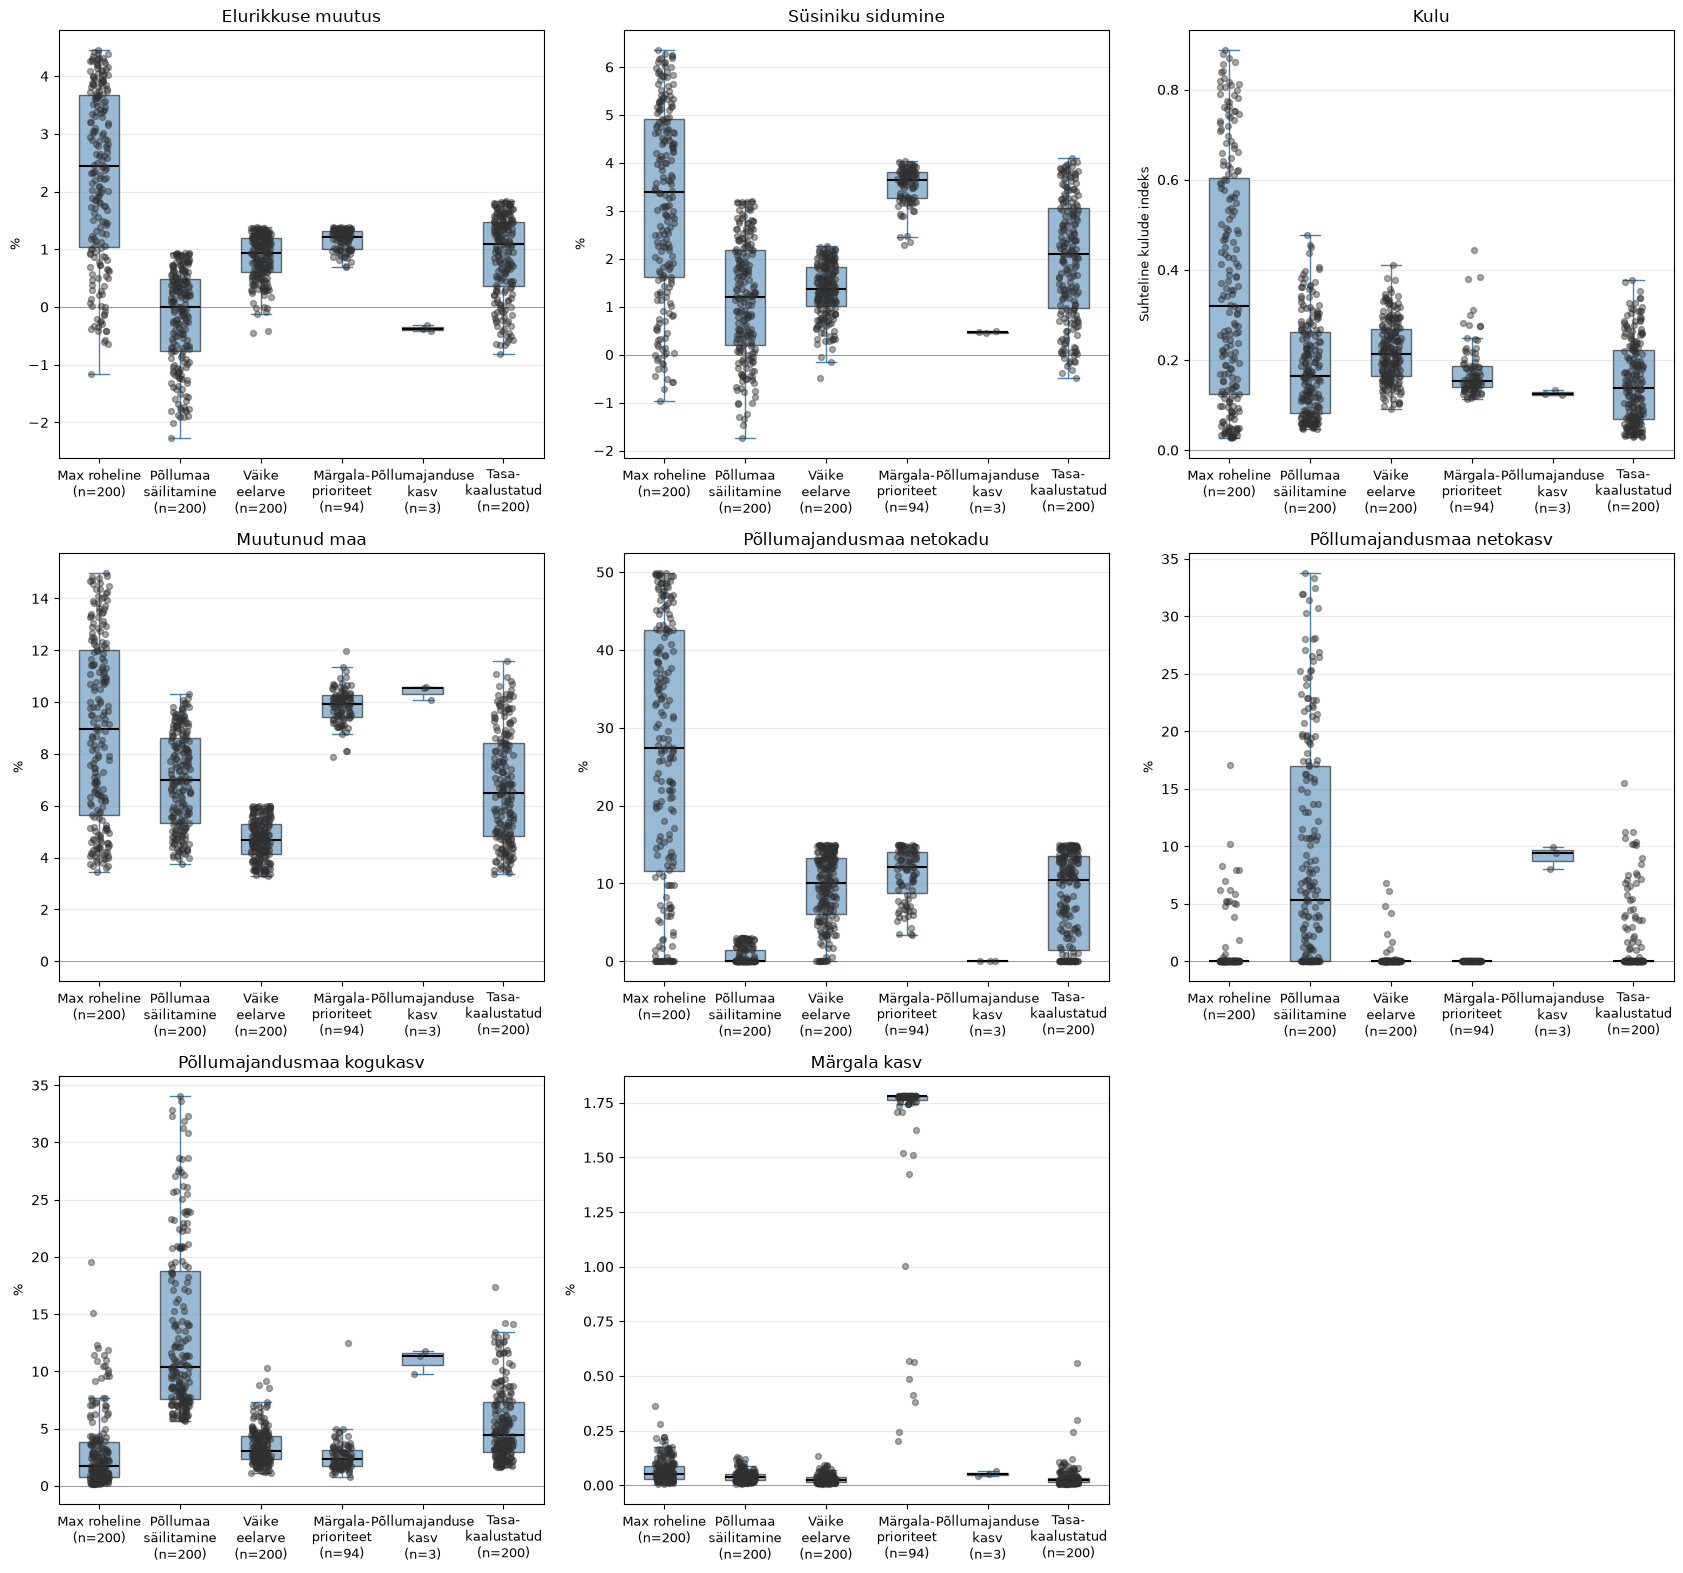

In [45]:
# Pareto-frontier distribution plots.
# Shows the same eight metrics as the representative-solution bar chart.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Combine all rank-0 / Pareto-frontier policies from every scenario.
all_pareto = pd.concat(
    [
        scenario_df.assign(scenario_key=scenario_name)
        for scenario_name, scenario_df in pareto_dfs.items()
    ],
    ignore_index=True,
)

scenario_order = list(SCENARIOS.keys())

scenario_labels_et = {
    "green_maximum": "Max roheline",
    "food_security": "Põllumaa\nsäilitamine",
    "low_budget": "Väike\neelarve",
    "wetland_priority": "Märgala-\nprioriteet",
    "sustainable_agriculture": "Põllumajanduse\nkasv",
    "balanced": "Tasa-\nkaalustatud",
}

# Bar-chart display label -> column name in pareto_dfs / all_pareto.

# Estonian display label -> Pareto-table column name
metric_columns = {
    "Elurikkuse muutus": "biodiversity_gain",
    "Süsiniku sidumine": "carbon_gain",
    "Kulu": "cost",
    "Muutunud maa": "changed_pct",
    "Põllumajandusmaa netokadu": "agriculture_loss_pct",
    "Põllumajandusmaa netokasv": "agriculture_gain_pct",
    "Põllumajandusmaa kogukasv": "gross_agriculture_gain_pct",
    "Märgala kasv": "wetland_gain_pct",
}

percent_metrics = {
    "Elurikkuse muutus",
    "Süsiniku sidumine",
    "Muutunud maa",
    "Põllumajandusmaa netokadu",
    "Põllumajandusmaa netokasv",
    "Põllumajandusmaa kogukasv",
    "Märgala kasv",
}

# Use the same metric order as the bar chart.
# A metric is omitted only if it was not saved for all Pareto policies.
boxplot_metrics = [
    label
    for label, column in metric_columns.items()
    if column in all_pareto.columns
]

missing_metrics = [
    label
    for label, column in metric_columns.items()
    if column not in all_pareto.columns
]

if missing_metrics:
    print("Pareto data does not contain these metrics:")
    print(missing_metrics)

n_cols = 3
n_rows = int(np.ceil(len(boxplot_metrics) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(17, 5.5 * n_rows),
    squeeze=False,
)
axes_flat = axes.flatten()

rng = np.random.default_rng(42)

for ax, metric_label in zip(axes_flat, boxplot_metrics):
    metric_column = metric_columns[metric_label]
    values_by_scenario = []

    for scenario in scenario_order:
        values = all_pareto.loc[
            all_pareto["scenario_key"] == scenario,
            metric_column,
        ].dropna().to_numpy()

        # Convert shares to percentages, but preserve the cost index.
        if metric_label in percent_metrics:
            values = values * 100

        values_by_scenario.append(values)

    positions = np.arange(1, len(scenario_order) + 1)

    ax.boxplot(
        values_by_scenario,
        positions=positions,
        patch_artist=True,
        showfliers=False,  # every solution is shown as a dot below
        boxprops={"facecolor": "steelblue", "alpha": 0.55},
        medianprops={"color": "black", "linewidth": 1.5},
        whiskerprops={"color": "steelblue"},
        capprops={"color": "steelblue"},
    )

    # Plot every Pareto solution.
    for position, values in zip(positions, values_by_scenario):
        jitter = rng.uniform(-0.12, 0.12, size=len(values))

        ax.scatter(
            position + jitter,
            values,
            s=18,
            color="#303030",
            alpha=0.42,
            zorder=3,
        )

    labels = [
        f"{scenario_labels_et.get(scenario, scenario)}\n(n={len(values)})"
        for scenario, values in zip(scenario_order, values_by_scenario)
    ]

    unit = "%" if metric_label in percent_metrics else "Suhteline kulude indeks"

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(metric_label, fontsize=12)
    ax.set_ylabel(unit, fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.35)

# Hide unused panels: 8 metrics in a 3 × 3 grid leaves one panel unused.
for ax in axes_flat[len(boxplot_metrics):]:
    ax.set_visible(False)

#fig.suptitle(
#    "Pareto-lahenduste jaotus stsenaariumide kaupa",
#    fontsize=15,
#    y=0.98,
#)

fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.savefig("plots/pareto_piiride_jaotus_lahenduste_kaupa.png")
plt.show()

## Action maps (scenario representative per scenario)

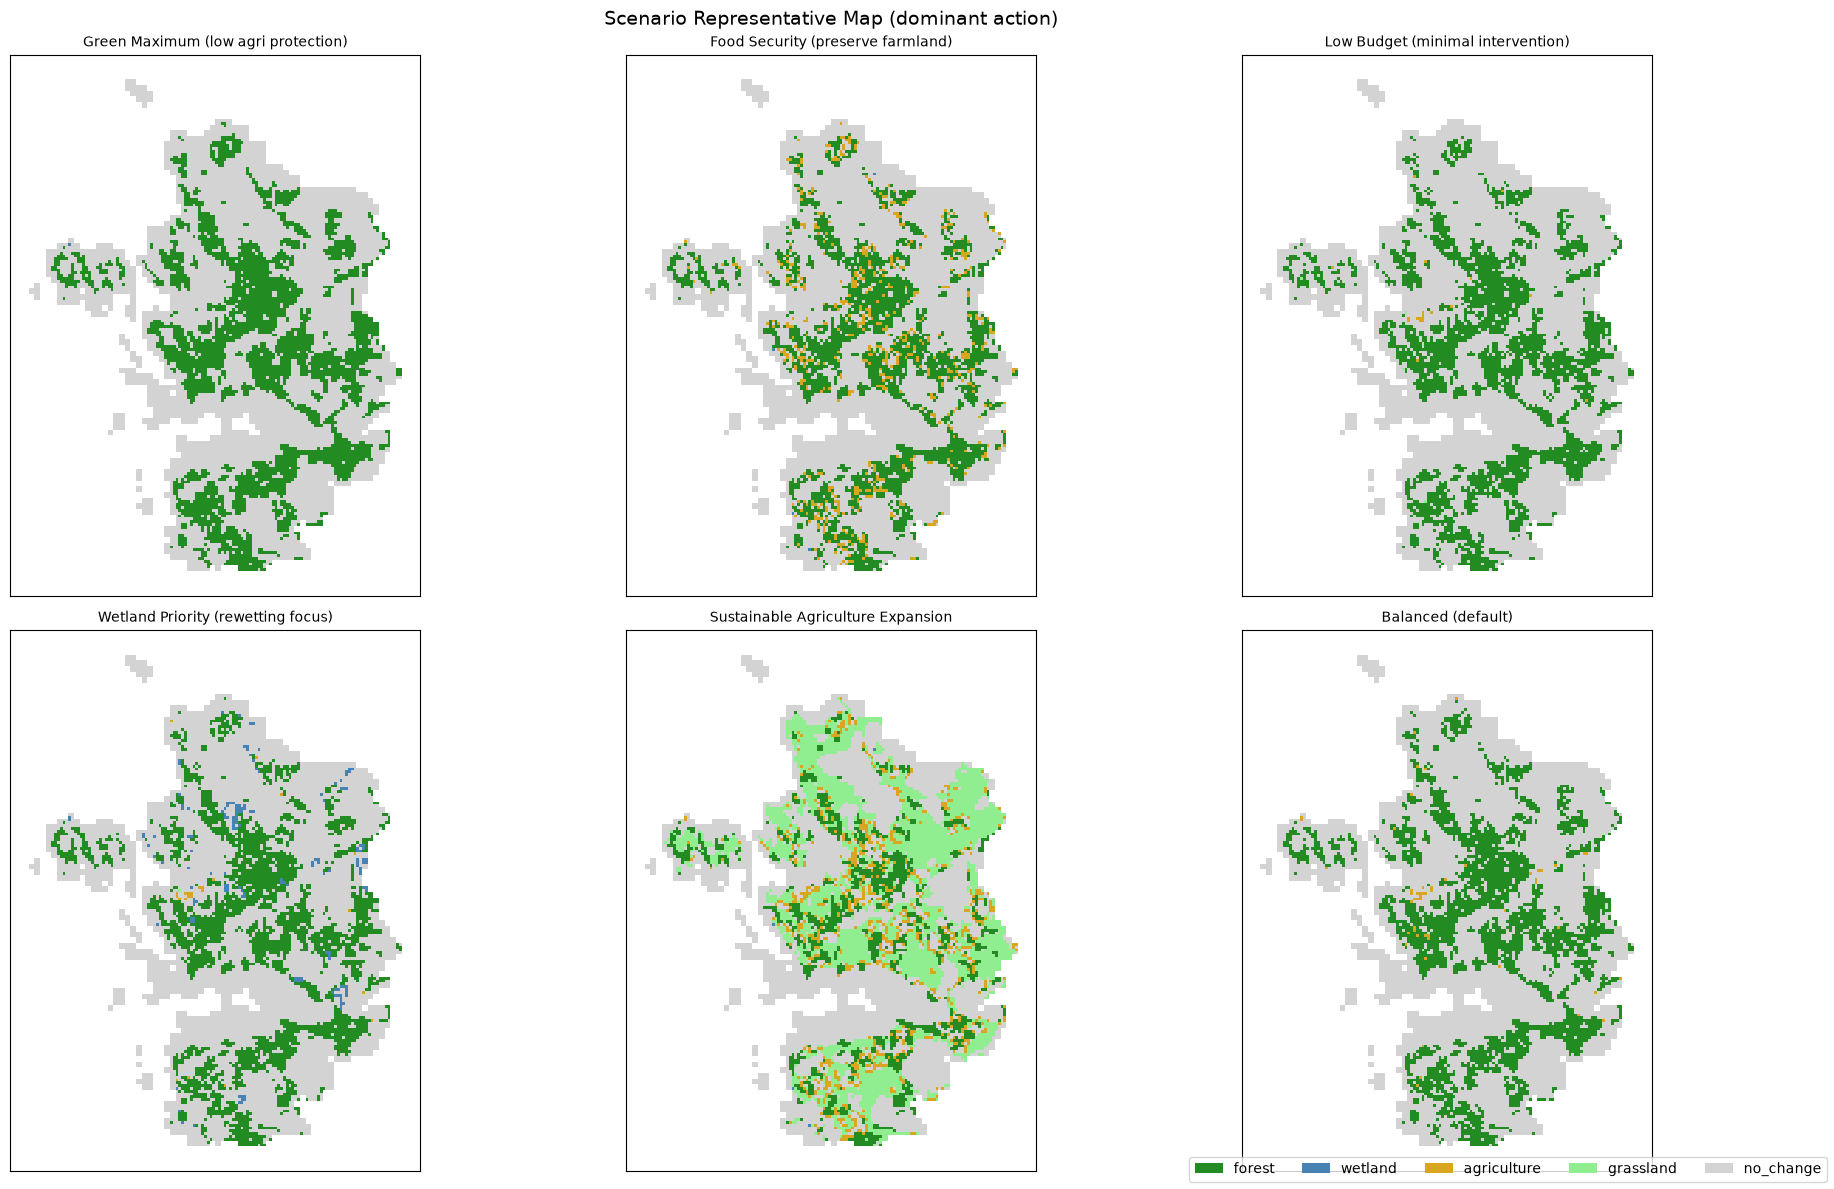

In [15]:
# Compute best policy targets for each scenario
groups = ["forest", "wetland", "agriculture", "grassland"]

features = features_df[FEATURE_COLUMNS].values.astype(np.float32)
feat_mean = features.mean(axis=0)
feat_std = features.std(axis=0)
feat_std[feat_std == 0] = 1.0
feat_norm = (features - feat_mean) / feat_std

n_cols = 3
n_rows = int(np.ceil(len(results) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes_flat = np.atleast_1d(axes).flatten()

for idx, (name, data) in enumerate(results.items()):
    ax = axes_flat[idx]

    # Reuse the scenario representative selected for the summary
    best_policy = selected_policies[name]

    # Compute delta
    targets = best_policy.prescribe(feat_norm)
    current = np.column_stack([features_df[f"{g}_pct"].values for g in groups])
    targets_norm = realize_targets(features_df, targets, data["config"])
    delta = targets_norm - current

    # Dominant action
    change_intensity = np.abs(delta).sum(axis=1) / 2.0
    dominant = np.array(groups)[delta.argmax(axis=1)]
    dominant[change_intensity < 0.05] = "no_change"

    # Map
    map_df = grid.copy()
    map_df["action"] = dominant

    color_map = {"forest": "#228B22", "wetland": "#4682B4",
                 "agriculture": "#DAA520", "grassland": "#90EE90", "no_change": "#D3D3D3"}
    for action, color in color_map.items():
        subset = map_df[map_df["action"] == action]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor="none")

    ax.set_title(f"{SCENARIOS[name]}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

# Hide unused subplots
for ax in axes_flat[len(results):]:
    ax.set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=a) for a, c in color_map.items()]
fig.legend(handles=legend_elements, loc="lower right", fontsize=10, ncol=5)

plt.suptitle("Scenario Representative Map (dominant action)", fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

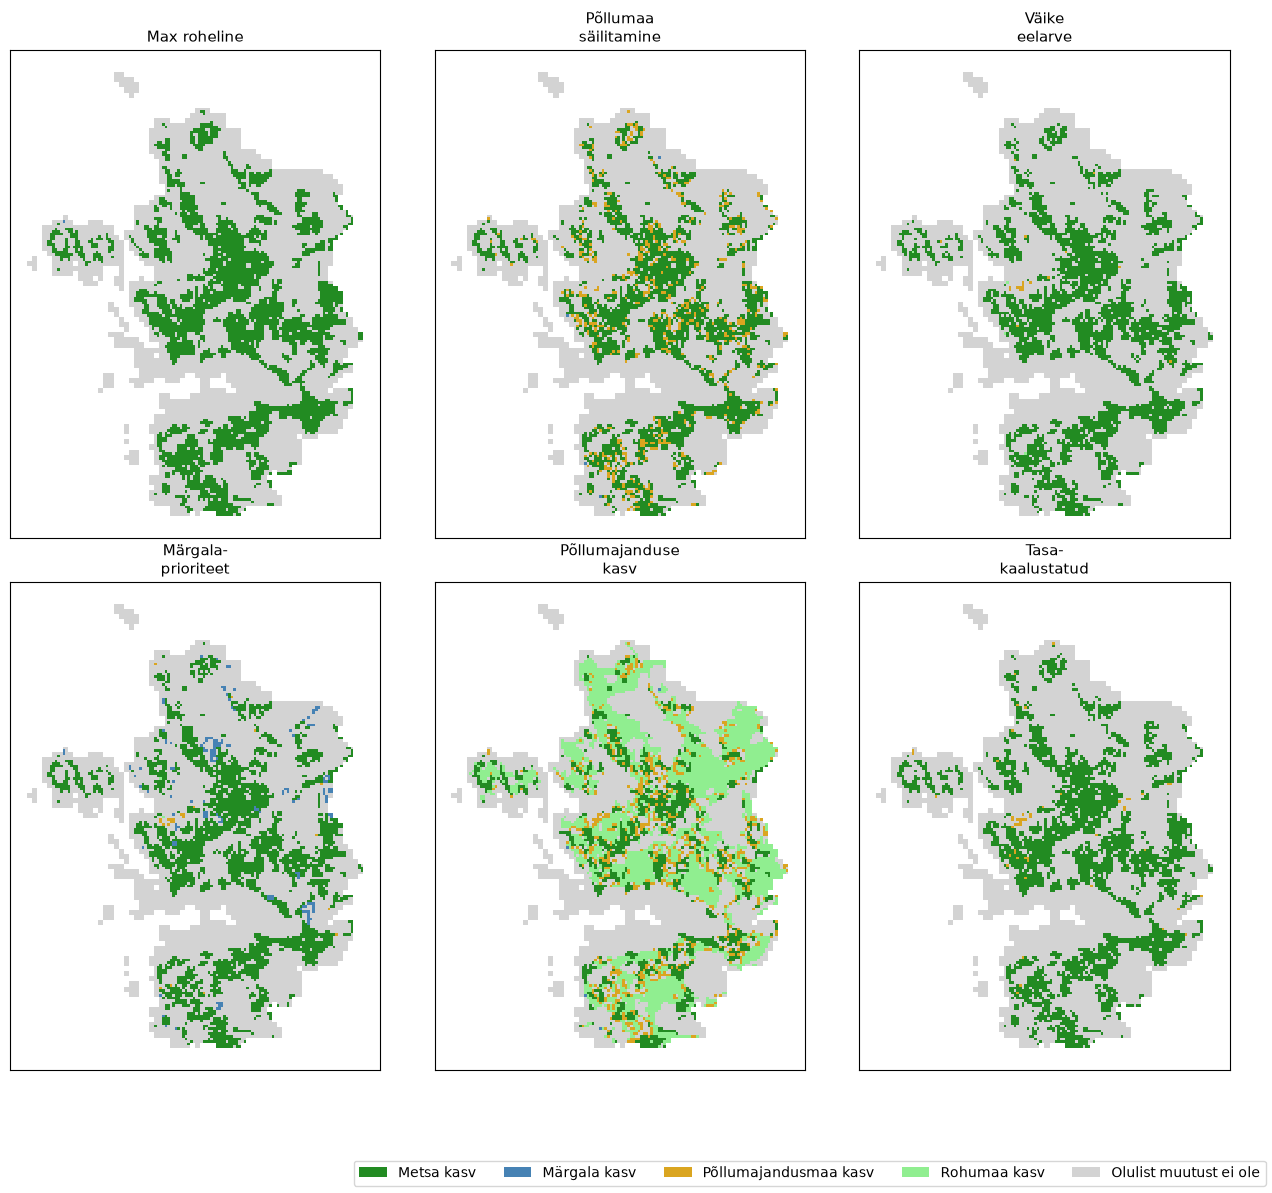

In [52]:
# Arvuta iga stsenaariumi esinduslahenduse maakasutuse muutused
groups = ["forest", "wetland", "agriculture", "grassland"]

features = features_df[FEATURE_COLUMNS].values.astype(np.float32)
feat_mean = features.mean(axis=0)
feat_std = features.std(axis=0)
feat_std[feat_std == 0] = 1.0
feat_norm = (features - feat_mean) / feat_std

scenario_labels_et = {
    "green_maximum": "Max roheline",
    "food_security": "Põllumaa\nsäilitamine",
    "low_budget": "Väike\neelarve",
    "wetland_priority": "Märgala-\nprioriteet",
    "sustainable_agriculture": "Põllumajanduse\nkasv",
    "balanced": "Tasa-\nkaalustatud",
}

action_labels_et = {
    "forest": "Metsa kasv",
    "wetland": "Märgala kasv",
    "agriculture": "Põllumajandusmaa kasv",
    "grassland": "Rohumaa kasv",
    "no_change": "Olulist muutust ei ole",
}

n_cols = 3
n_rows = int(np.ceil(len(results) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 6 * n_rows))
axes_flat = np.atleast_1d(axes).flatten()

for idx, (name, data) in enumerate(results.items()):
    ax = axes_flat[idx]

    # Kasuta kokkuvõtte jaoks valitud esinduslahendust
    best_policy = selected_policies[name]

    # Arvuta muutus võrreldes praeguse maakasutusega
    targets = best_policy.prescribe(feat_norm)

    current = np.column_stack(
        [features_df[f"{group}_pct"].values for group in groups]
    )

    targets_norm = realize_targets(features_df, targets, data["config"])
    delta = targets_norm - current

    # Leia igas ruudus suurima positiivse muutusega maakasutuse tüüp
    change_intensity = np.abs(delta).sum(axis=1) / 2.0
    dominant = np.array(groups)[delta.argmax(axis=1)]
    dominant[change_intensity < 0.05] = "no_change"

    # Koosta kaart
    map_df = grid.copy()
    map_df["action"] = dominant

    color_map = {
        "forest": "#228B22",
        "wetland": "#4682B4",
        "agriculture": "#DAA520",
        "grassland": "#90EE90",
        "no_change": "#D3D3D3",
    }

    for action, color in color_map.items():
        subset = map_df[map_df["action"] == action]

        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor="none")

    ax.set_title(scenario_labels_et.get(name, SCENARIOS[name]), fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

# Peida kasutamata alamjoonised
for ax in axes_flat[len(results):]:
    ax.set_visible(False)

# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color, label=action_labels_et[action])
    for action, color in color_map.items()
]

fig.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=10,
    ncol=5,
)

#plt.suptitle(
#    "Stsenaariumide esinduslahenduste kaardid\n(domineeriv maakasutuse muutus)",
#    fontsize=14,
#)

#plt.tight_layout()
fig.subplots_adjust(
    left=0.01,
    right=0.99,
    bottom=0.10,
    top=0.95,
    wspace=0.00,
    hspace=0.09,
)
plt.savefig('plots/top_muutus_stsneaariumite_kaupa_kaart.png')
plt.show()
plt.close(fig)

## Change intensity comparison

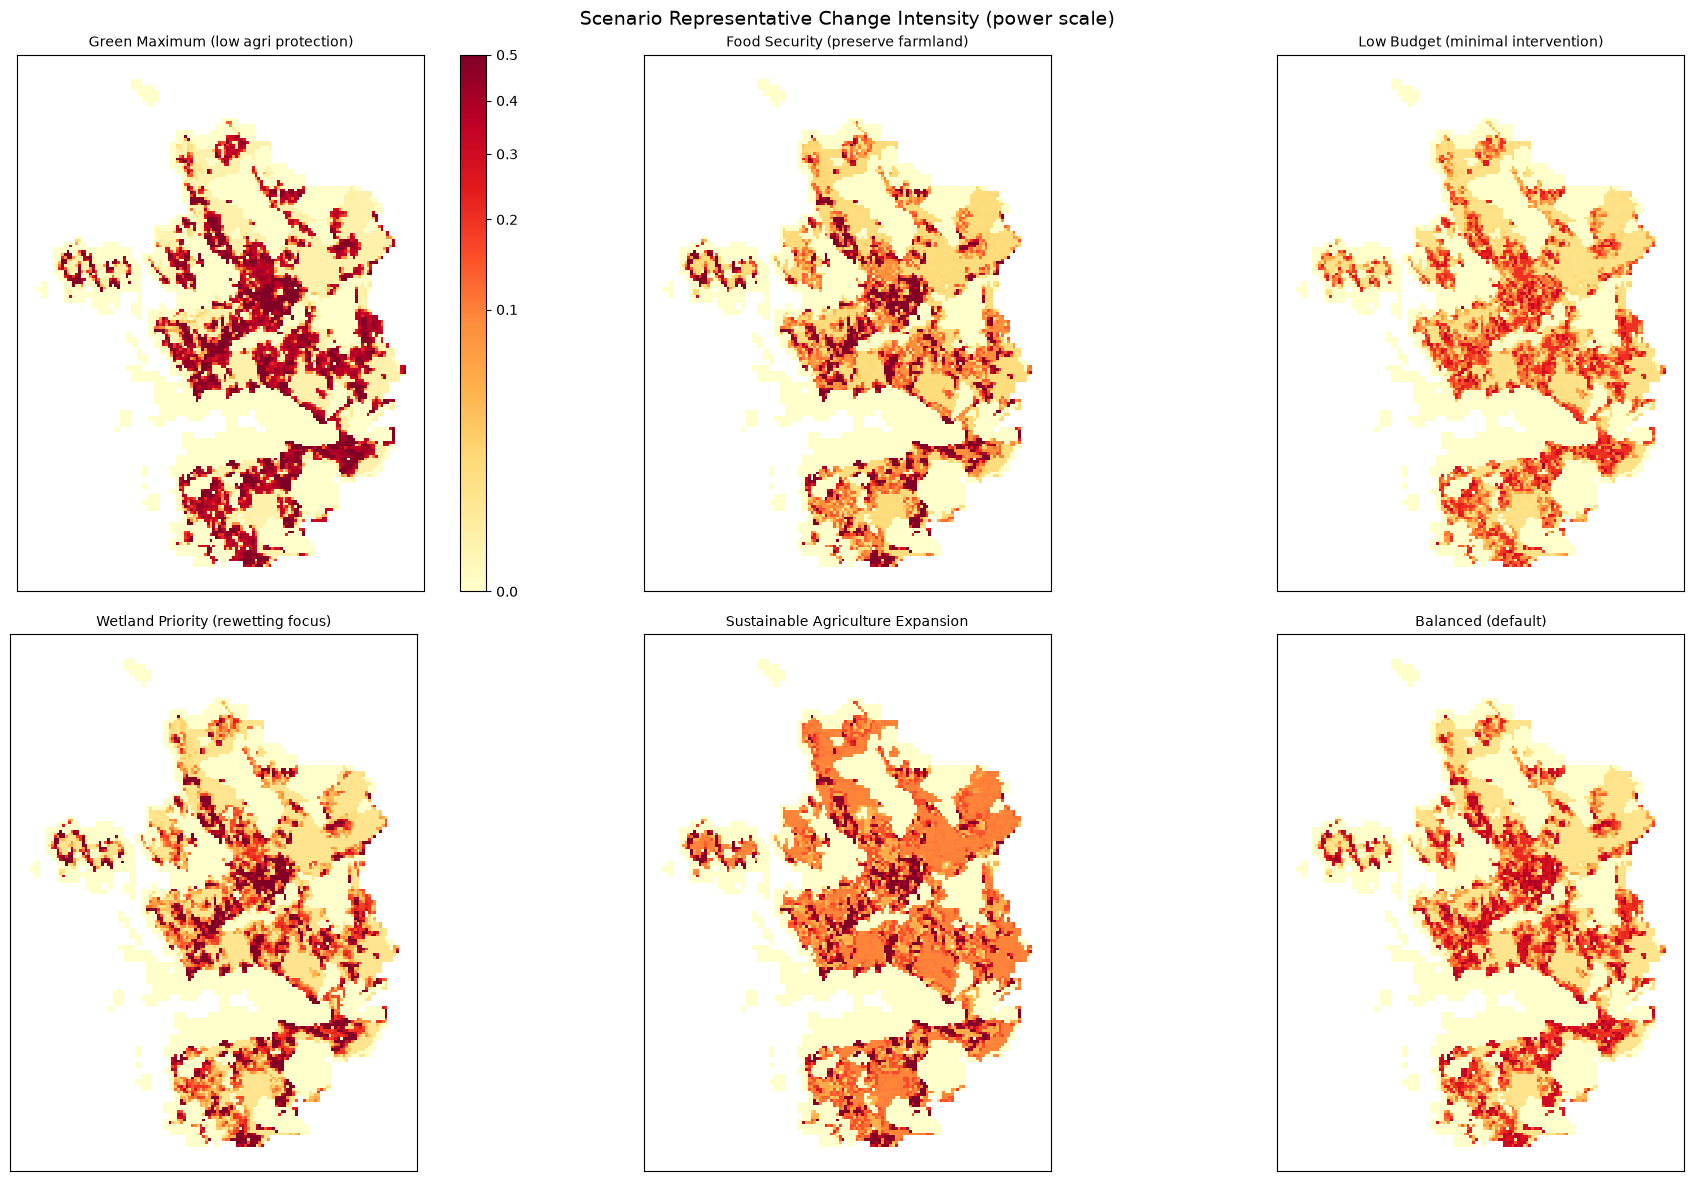

In [16]:
from matplotlib.colors import PowerNorm

n_cols = 3
n_rows = int(np.ceil(len(results) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes_flat = np.atleast_1d(axes).flatten()

for idx, (name, data) in enumerate(results.items()):
    ax = axes_flat[idx]

    # Reuse the scenario representative selected for the summary
    best_policy = selected_policies[name]

    targets = best_policy.prescribe(feat_norm)
    current = np.column_stack([features_df[f"{g}_pct"].values for g in groups])
    targets_norm = realize_targets(features_df, targets, data["config"])
    delta = targets_norm - current

    intensity = np.abs(delta).sum(axis=1) / 2.0
    map_df = grid.copy()
    map_df["intensity"] = intensity

    map_df.plot(column="intensity", ax=ax, cmap="YlOrRd",
                norm=PowerNorm(gamma=0.4, vmin=0, vmax=0.5),
                legend=(idx == 0))
    ax.set_title(f"{SCENARIOS[name]}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes_flat[len(results):]:
    ax.set_visible(False)

plt.suptitle("Scenario Representative Change Intensity (power scale)", fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

## Carbon tonnes

,Stsenaarium,ktCO₂/aasta (madal),ktCO₂/aasta (keskmine),ktCO₂/aasta (kõrge),Muutunud maa (ha),Muutunud maa (km²)
0,Max roheline,269.0,425.5,725.0,"41,304",413.0
1,Toidu- julgeolek,65.2,166.8,310.4,"26,776",267.8
2,Väike eelarve,68.7,119.9,211.3,"14,036",140.4
3,Märgala- prioriteet,127.8,227.8,391.9,"27,687",276.9
4,Põllumajanduse kasv,-37.0,32.3,114.7,"28,972",289.7
5,Tasa- kaalustatud,82.6,142.7,245.2,"18,200",182.0


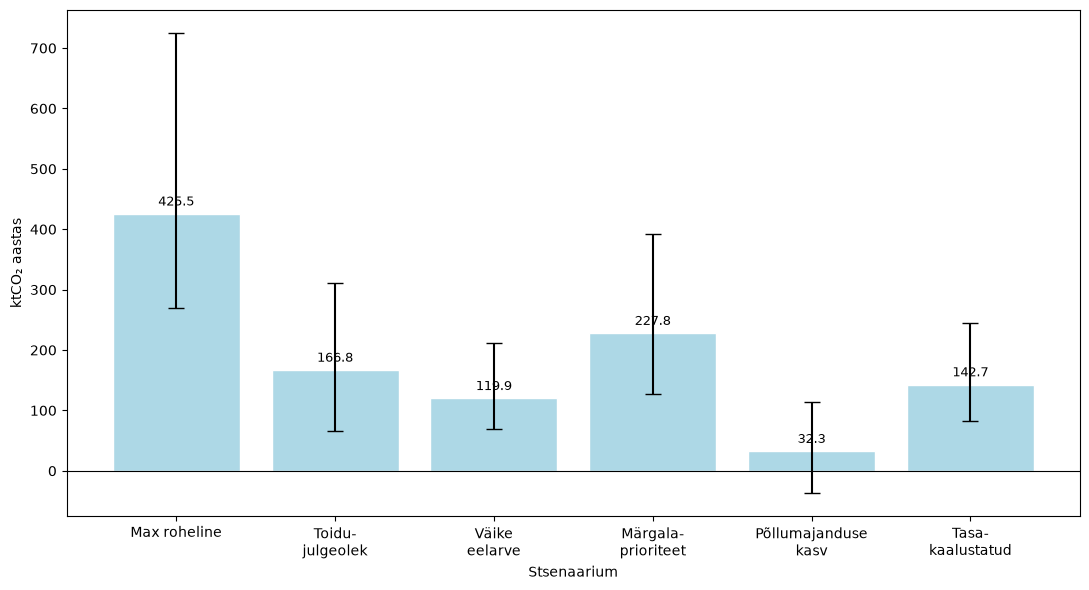

In [42]:
from estonia_landuse.simulator.carbon_tonnes import summarize_carbon_tonnes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

scenario_labels_et = {
    "green_maximum": "Max roheline",
    "food_security": "Toidu-\njulgeolek",
    "low_budget": "Väike\neelarve",
    "wetland_priority": "Märgala-\nprioriteet",
    "sustainable_agriculture": "Põllumajanduse\nkasv",
    "balanced": "Tasa-\nkaalustatud",
}

carbon_tonnes_results = []

for name, data in results.items():
    policy = selected_policies[name]

    raw_targets = policy.prescribe(feat_norm)
    targets_norm = realize_targets(features_df, raw_targets, data["config"])
    report = summarize_carbon_tonnes(features_df, targets_norm)

    carbon_tonnes_results.append({
        "Stsenaarium": scenario_labels_et.get(name, name),
        "ktCO₂/aasta (madal)": report["total_tco2_per_year_low"] / 1_000,
        "ktCO₂/aasta (keskmine)": report["total_tco2_per_year_mid"] / 1_000,
        "ktCO₂/aasta (kõrge)": report["total_tco2_per_year_high"] / 1_000,
        "Muutunud maa (ha)": report["total_ha_changed"],
        "Muutunud maa (km²)": report["total_km2_changed"],
    })

carbon_tonnes_summary = pd.DataFrame(carbon_tonnes_results)

display(
    carbon_tonnes_summary.style.format({
        "ktCO₂/aasta (madal)": "{:,.1f}",
        "ktCO₂/aasta (keskmine)": "{:,.1f}",
        "ktCO₂/aasta (kõrge)": "{:,.1f}",
        "Muutunud maa (ha)": "{:,.0f}",
        "Muutunud maa (km²)": "{:,.1f}",
    })
)

plot_df = carbon_tonnes_summary.copy()

keskmine = plot_df["ktCO₂/aasta (keskmine)"].to_numpy()
madal = plot_df["ktCO₂/aasta (madal)"].to_numpy()
kõrge = plot_df["ktCO₂/aasta (kõrge)"].to_numpy()

veapiirid = np.vstack([
    keskmine - madal,
    kõrge - keskmine,
])

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    plot_df["Stsenaarium"],
    keskmine,
    yerr=veapiirid,
    capsize=6,
    color="lightblue",
    edgecolor="white",
)

ax.axhline(0, color="black", linewidth=0.8)
#ax.set_title("Stsenaariumide hinnanguline süsinikumõju")
ax.set_ylabel("ktCO₂ aastas")
ax.set_xlabel("Stsenaarium")
ax.tick_params(axis="x", labelsize=10)

for indeks, väärtus in enumerate(keskmine):
    ax.annotate(
        f"{väärtus:,.1f}",
        (indeks, väärtus),
        xytext=(0, 6 if väärtus >= 0 else -14),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

fig.tight_layout()
plt.savefig(
    "plots/stsenaariumide_süsinikumõju_ktco2.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Save results

In [17]:
# Save pareto data for later analysis
all_pareto = []
for name, pdf in pareto_dfs.items():
    pdf_copy = pdf.copy()
    pdf_copy["scenario"] = name
    pdf_copy["is_representative"] = (
        pdf_copy["id"] == int(representatives[name]["id"])
    )
    all_pareto.append(pdf_copy)

pd.concat(all_pareto).to_parquet(RESULTS_DIR / "scenario_comparison.parquet", index=False)
summary.to_parquet(RESULTS_DIR / "scenario_summary.parquet", index=False)
print(f"Saved Pareto metrics to {RESULTS_DIR / 'scenario_comparison.parquet'}")
print(f"Saved scenario summary to {RESULTS_DIR / 'scenario_summary.parquet'}")

# Save per-cell action maps as GeoPackage (for interactive visualizations)
maps_dir = RESULTS_DIR / "scenario_maps"
maps_dir.mkdir(exist_ok=True)

for name, data in results.items():
    best_policy = selected_policies[name]

    targets = best_policy.prescribe(feat_norm)
    current = np.column_stack([features_df[f"{g}_pct"].values for g in groups])
    targets_norm = realize_targets(features_df, targets, data["config"])
    delta = targets_norm - current

    # Build map dataframe
    map_gdf = grid[["cell_id", "geometry"]].copy()
    map_gdf["change_intensity"] = np.abs(delta).sum(axis=1) / 2.0
    dominant = np.array(groups)[delta.argmax(axis=1)]
    dominant[map_gdf["change_intensity"].values < 0.05] = "no_change"
    map_gdf["action"] = dominant
    for i, g in enumerate(groups):
        map_gdf[f"current_{g}"] = current[:, i]
        map_gdf[f"target_{g}"] = targets_norm[:, i]
        map_gdf[f"delta_{g}"] = delta[:, i]

    map_gdf.to_file(maps_dir / f"{name}.gpkg", driver="GPKG")

print(f"Saved {len(results)} scenario maps to {maps_dir}/")
print("Each contains: cell_id, geometry, action, change_intensity, current/target/delta per group")

Saved Pareto metrics to ..\data\processed\learned_carbon\scenario_comparison.parquet
Saved scenario summary to ..\data\processed\learned_carbon\scenario_summary.parquet
Saved 6 scenario maps to ..\data\processed\learned_carbon\scenario_maps/
Each contains: cell_id, geometry, action, change_intensity, current/target/delta per group


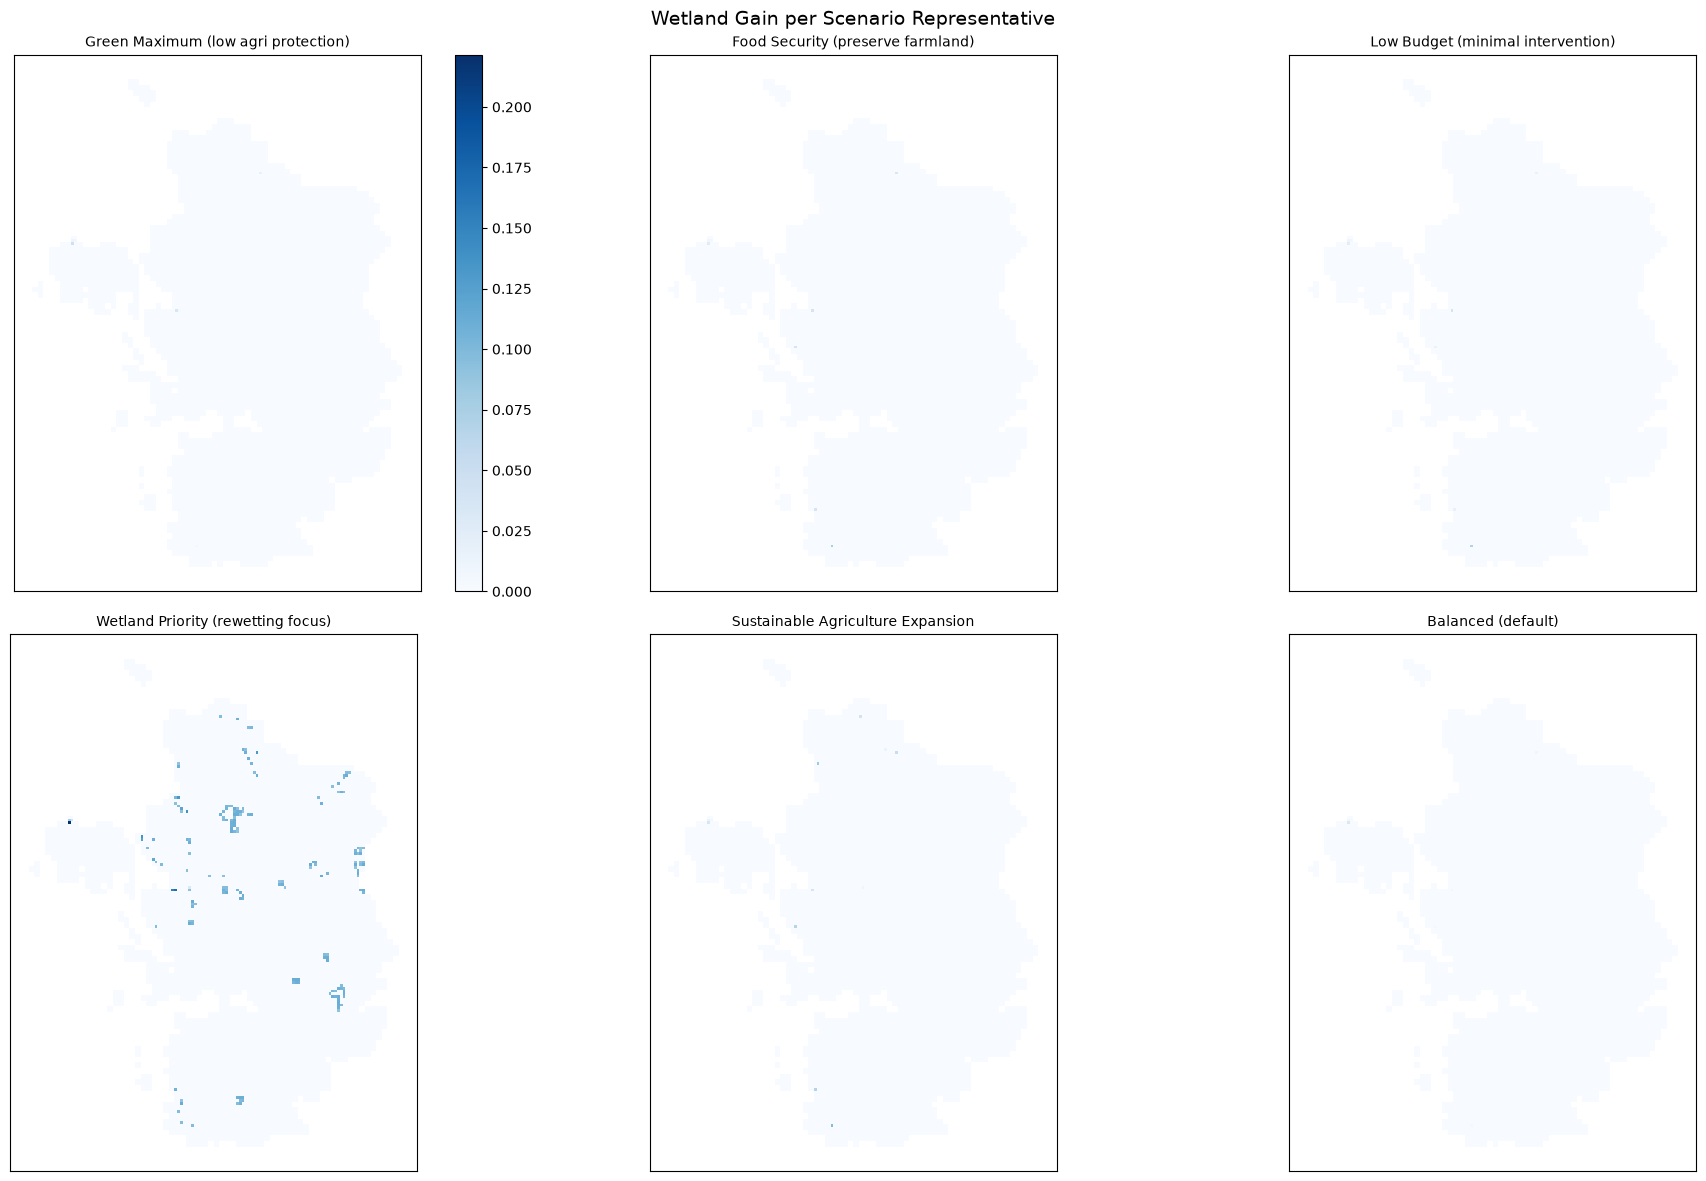

In [18]:
# Show wetland gain directly; dominant-action maps can hide rewetting.
selected_wetland_maps = {}
shared_wetland_max = 0.0
for name, data in results.items():
    best_policy = selected_policies[name]
    targets = best_policy.prescribe(feat_norm)
    current = np.column_stack(
        [features_df[f"{group}_pct"].values for group in groups]
    )
    targets_norm = realize_targets(
        features_df, targets, data["config"]
    )
    delta = targets_norm - current
    map_df = grid.copy()
    map_df["wetland_gain"] = np.clip(delta[:, 1], 0, None)
    selected_wetland_maps[name] = map_df
    shared_wetland_max = max(
        shared_wetland_max, float(map_df["wetland_gain"].max())
    )

shared_wetland_max = max(shared_wetland_max, 1e-12)
n_cols = 3
n_rows = int(np.ceil(len(results) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes_flat = np.atleast_1d(axes).flatten()
for idx, name in enumerate(results):
    ax = axes_flat[idx]
    selected_wetland_maps[name].plot(
        column="wetland_gain",
        ax=ax,
        cmap="Blues",
        vmin=0,
        vmax=shared_wetland_max,
        legend=(idx == 0),
    )
    ax.set_title(SCENARIOS[name], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axes_flat[len(results):]:
    ax.set_visible(False)
plt.suptitle("Wetland Gain per Scenario Representative", fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)